In [45]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

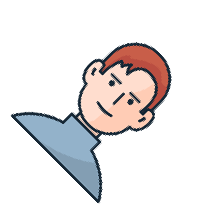

In [42]:
# input parameters
height = 150
width = 150
theta_deg = 45

# load image
img = Image.open('../img/rotation_image.png')

# resize image if needed
h = height if height else img.height
w = width if width else img.width

img = img.resize((h, w))

# convert img to array
img_array = np.array(img)

# rotation matrix
theta_rad = np.deg2rad(theta_deg)
cosine = np.cos(theta_rad)
sine = np.sin(theta_rad)

R = np.array([[cosine, -sine],
             [sine, cosine]])

# center of image
cx, cy = w/2, h/2

# output array (larger to fit rotated image)
new_size = int(np.linalg.norm(np.array([w, h]))) + 2 # int(np.sqrt(w**2 + h**2))
rotated = np.zeros((new_size, new_size, 4), dtype=np.uint8)
new_cx, new_cy = new_size//2, new_size//2

# for each pixel in the ORIGINAL image (backward mapping=FILLS ALL PIXELS)
for y in range(new_size):
    for x in range(new_size):
        # move to center
        p = np.array([x - new_cx, y - new_cy])
        
        # apply INVERSE rotation
        p_orig = R.T @ p
        
        # move back to original center
        orig_x = int(round(p_orig[0] + cx))
        orig_y = int(round(p_orig[1] + cy))
        
        # If within bounds, copy pixel
        if 0 <= orig_x < w and 0 <= orig_y < h:
            rotated[y, x] = img_array[orig_y, orig_x]

# show
rotated_img = Image.fromarray(rotated)
rotated_img

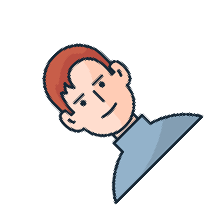

In [52]:
def rotate_image(img_path, theta_deg, height=None, width=None):
    # load image
    img = Image.open(img_path)
    
    # resize image if needed
    h = height if height else img.height
    w = width if width else img.width
    
    img = img.resize((h, w))
    
    # convert img to array
    img_array = np.array(img)
    
    # rotation matrix
    theta_rad = np.deg2rad(theta_deg)
    cosine = np.cos(theta_rad)
    sine = np.sin(theta_rad)
    
    R = np.array([[cosine, -sine],
                 [sine, cosine]])
    
    # center of image
    cx, cy = w/2, h/2
    
    # output array (larger to fit rotated image)
    new_size = int(np.linalg.norm(np.array([w, h]))) + 2 # int(np.sqrt(w**2 + h**2))
    rotated = np.zeros((new_size, new_size, 4), dtype=np.uint8)
    new_cx, new_cy = new_size//2, new_size//2
    
    # for each pixel in the ORIGINAL image (backward mapping=FILLS ALL PIXELS)
    for y in range(new_size):
        for x in range(new_size):
            # move to center
            p = np.array([x - new_cx, y - new_cy])
            
            # apply INVERSE rotation
            p_orig = R.T @ p
            
            # move back to original center
            orig_x = int(round(p_orig[0] + cx))
            orig_y = int(round(p_orig[1] + cy))
            
            # If within bounds, copy pixel
            if 0 <= orig_x < w and 0 <= orig_y < h:
                rotated[y, x] = img_array[orig_y, orig_x]

    return rotated

# show
image_path='../img/rotation_image.png'
rotated_matrix = rotate_image(img_path=image_path, theta_deg=-45, height=150, width=150)
Image.fromarray(rotated_matrix)

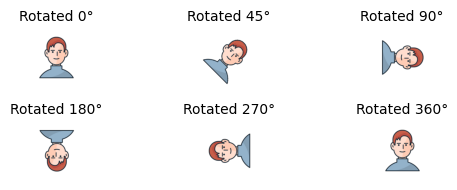

In [57]:
degrees = [0, 45, 90, 180, 270, 360]
image_path='../img/rotation_image.png'

plt.figure(figsize=(6, 2))


for i, theta_deg in enumerate(degrees):
    img_array = rotate_image(img_path=image_path, theta_deg=theta_deg, height=150, width=150)
    plt.subplot(2, 3, i+1)
    plt.imshow(img_array)
    plt.title(f'Rotated {theta_deg}°', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig('017_rotate_image.png', dpi=200)
plt.show()